# Phase 5. From model to recommendation

Phases 3 and 4 answered "does price and promotion affect quantity, and
does that effect vary." This phase asks the question a stakeholder
actually cares about: given everything estimated so far, what should the
retailer actually do differently, and what is that worth in dollars.

The approach: fit one demand model that lets price, promotion type, and
discount depth move independently, then solve for the discount depth that
maximizes revenue for each category and promo type, then compare that
optimum to what the retailer is actually doing in the data.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../warehouse.duckdb', read_only=True)

## 1. One unified model

Phase 4 fit two separate models, one for the store size interaction and
one for the discount depth interaction. Optimizing needs both effects in
a single equation so the discount depth recommendation properly accounts
for store size and vice versa. Price here is again the regular, pre
discount price, with `discount_pct` carrying the depth of whatever cut is
happening that week, same reasoning as Phase 4 section 3.

In [2]:
store_size = con.execute(
    "SELECT store_id, COUNT(*) AS store_total_txns FROM fact_transactions GROUP BY store_id"
).fetchdf()

query = """
WITH agg AS (
    SELECT t.product_id, t.store_id, t.week, p.product_category,
        SUM(t.quantity) AS quantity, SUM(t.sales_value) AS sales_value,
        SUM(t.retail_disc) AS retail_disc
    FROM fact_transactions t
    JOIN dim_product p ON t.product_id = p.product_id
    WHERE p.product_category IN ('EGGS', 'BATH TISSUES')
    GROUP BY t.product_id, t.store_id, t.week, p.product_category
)
SELECT a.*, COALESCE(pr.is_displayed,0) AS is_displayed, COALESCE(pr.is_mailed,0) AS is_mailed
FROM agg a
LEFT JOIN fact_promotions pr ON a.product_id=pr.product_id AND a.store_id=pr.store_id AND a.week=pr.week
"""
df = con.execute(query).fetchdf()
df['gross_value'] = df['sales_value'] + df['retail_disc'].abs()
df['unit_price'] = df['gross_value'] / df['quantity']
df['discount_pct'] = (df['retail_disc'].abs() / df['gross_value'].replace(0, np.nan)).fillna(0)
df = df[df.unit_price > 0]
df['log_qty'] = np.log(df['quantity'])
df['log_price'] = np.log(df['unit_price'])
df = df.merge(store_size, on='store_id', how='left')
df['log_store_size_c'] = np.log(df['store_total_txns']) - np.log(df['store_total_txns']).mean()

models = {}
for cat in ['EGGS','BATH TISSUES']:
    sub = df[df.product_category==cat].copy()
    m = smf.ols(
        'log_qty ~ log_price + is_displayed*discount_pct + is_mailed*discount_pct'
        ' + is_displayed*log_store_size_c + is_mailed*log_store_size_c'
        ' + C(product_id) + C(store_id) + C(week)',
        data=sub
    ).fit(cov_type='cluster', cov_kwds={'groups': sub['product_id']})
    models[cat] = m
    print(f'{cat}: R2={m.rsquared:.3f}, n={int(m.nobs)}')

EGGS: R2=0.278, n=11534


BATH TISSUES: R2=0.298, n=7249


## 2. Solving for the revenue maximizing discount depth

For a product already running a display or mailer, revenue as a function
of discount depth d looks like

Revenue(d) is proportional to (1 minus d) times Quantity(d)

and the fitted model says Quantity(d) grows like exp(k times d), where k
is the discount coefficient plus the relevant interaction term (display or
mailer). Taking the derivative and solving for where it crosses zero gives

d star equals 1 minus 1 over k, when k is greater than 1

and d star equals 0 otherwise. The intuition in plain terms: if going one
point deeper on discount grows quantity by more than one percent, that
extra point pays for itself and it is worth going deeper still. Once
quantity growth per point of discount drops below one percent, further
discounting is pure margin giveaway with no volume payoff big enough to
cover it.

In [3]:
def solve_optimal_discount(model, promo_col):
    b_disc = model.params['discount_pct']
    b_int = model.params[f'{promo_col}:discount_pct']
    k = b_disc + b_int
    d_star = max(0.0, 1 - 1/k) if k > 1 else 0.0
    return k, d_star

rows = []
for cat in ['EGGS','BATH TISSUES']:
    for promo_col, label in [('is_displayed','Display'), ('is_mailed','Mailer')]:
        k, d_star = solve_optimal_discount(models[cat], promo_col)
        actual_avg = df[(df.product_category==cat) & (df[promo_col]==1)]['discount_pct'].mean()
        rows.append({
            'category': cat.title(), 'promo_type': label,
            'combined_slope_k': round(k,3),
            'model_optimal_discount_pct': round(d_star*100,1),
            'current_avg_discount_pct': round(actual_avg*100,1)
        })
opt_table = pd.DataFrame(rows)
opt_table

,category,promo_type,combined_slope_k,model_optimal_discount_pct,current_avg_discount_pct
0,Eggs,Display,0.173,0.0,20.5
1,Eggs,Mailer,1.671,40.1,25.6
2,Bath Tissues,Display,0.117,0.0,24.1
3,Bath Tissues,Mailer,-0.017,0.0,27.6


**Reading this.** Eggs mailers are the one case where the current
average discount, about 25.6 percent, sits below the model implied optimum
of about 40 percent, meaning volume keeps growing fast enough per point of
discount to justify going deeper. Every other combination (Eggs display,
Bath Tissues display, Bath Tissues mailer) has a combined slope under 1,
meaning the model implied optimum is 0 percent: for those, deeper
discounting is not earning back its own cost in volume, and the current
practice (20 to 28 percent average discount) is likely giving away margin
with limited extra volume to show for it.

One useful check before trusting a number this specific: is 40 percent
within the range of discounts actually observed for Eggs mailers, or is
this the model guessing far outside its data. About 12 percent of Eggs
mailer weeks already ran at a discount above 40 percent, and the maximum
observed is 72 percent, so this recommendation is an interpolation within
the existing data, not a wild extrapolation.

## 3. What is that worth in revenue

For each category and promo type, recompute quantity and net revenue at
the model implied optimal discount instead of the discount that actually
happened, row by row, then sum the difference against actual observed
revenue.

In [4]:
def revenue_scenario(cat, promo_col, new_discount):
    m = models[cat]
    b_disc = m.params['discount_pct']
    b_interact = m.params[f'{promo_col}:discount_pct']
    sub = df[(df.product_category==cat) & (df[promo_col]==1)].copy()
    actual_revenue = sub['sales_value'].sum()
    delta_discount = new_discount - sub['discount_pct']
    delta_lp = delta_discount * (b_disc + b_interact)
    new_qty = sub['quantity'] * np.exp(delta_lp)
    new_net_price = sub['unit_price'] * (1 - new_discount)
    new_revenue = (new_net_price * new_qty).sum()
    return actual_revenue, new_revenue, new_revenue - actual_revenue

scenario_rows = []
targets = [('EGGS','is_mailed',0.40,'Mailer to 40% discount'),
           ('EGGS','is_displayed',0.0,'Display to 0% discount'),
           ('BATH TISSUES','is_displayed',0.0,'Display to 0% discount'),
           ('BATH TISSUES','is_mailed',0.0,'Mailer to 0% discount')]
for cat, promo_col, target, label in targets:
    actual_rev, new_rev, delta = revenue_scenario(cat, promo_col, target)
    scenario_rows.append({
        'category': cat.title(), 'change': label,
        'actual_revenue': round(actual_rev), 'scenario_revenue': round(new_rev),
        'delta': round(delta), 'pct_change': round(delta/actual_rev*100,1)
    })
scenario_df = pd.DataFrame(scenario_rows)
scenario_df

,category,change,actual_revenue,scenario_revenue,delta,pct_change
0,Eggs,Mailer to 40% discount,4641,4853,213,4.6
1,Eggs,Display to 0% discount,4032,5087,1055,26.2
2,Bath Tissues,Display to 0% discount,6385,8708,2324,36.4
3,Bath Tissues,Mailer to 0% discount,7160,10447,3286,45.9


<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_614/2556312706.py:14: SyntaxWarning: invalid escape sequence '\$'
  print(f'Combined estimated opportunity: \${total_delta:,.0f}, a {total_delta/total_actual*100:.1f} percent lift'
/tmp/ipykernel_614/2556312706.py:15: SyntaxWarning: invalid escape sequence '\$'
  f' on the \${total_actual:,.0f} of revenue these four promo programs generated in the observed period')


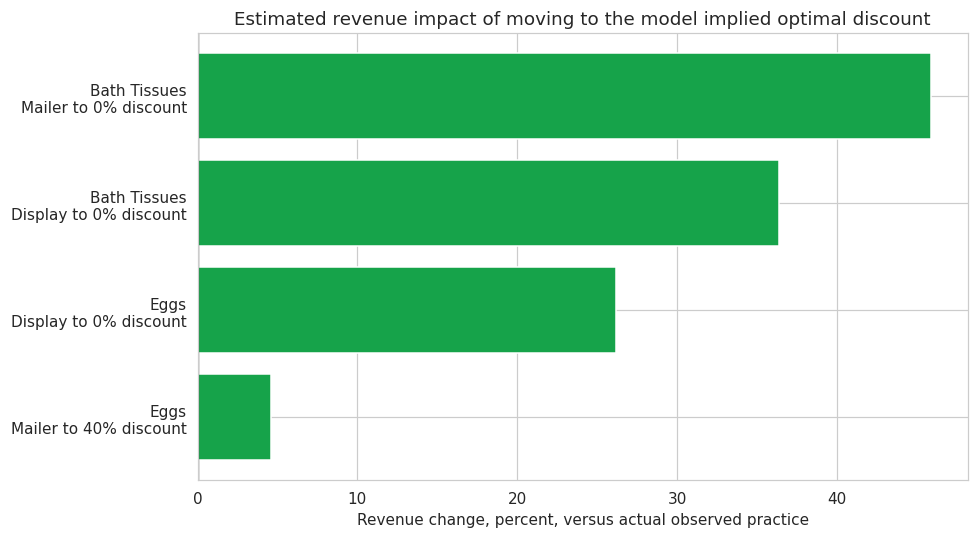

Combined estimated opportunity: \$6,878, a 31.0 percent lift on the \$22,218 of revenue these four promo programs generated in the observed period


In [5]:
fig, ax = plt.subplots(figsize=(9,5))
colors = ['#16a34a' if x > 0 else '#dc2626' for x in scenario_df['pct_change']]
labels = scenario_df['category'] + '\n' + scenario_df['change']
ax.barh(labels, scenario_df['pct_change'], color=colors)
ax.set_xlabel('Revenue change, percent, versus actual observed practice')
ax.set_title('Estimated revenue impact of moving to the model implied optimal discount')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/10_optimization_revenue_impact.png', bbox_inches='tight')
plt.show()

total_delta = scenario_df['delta'].sum()
total_actual = scenario_df['actual_revenue'].sum()
print(f'Combined estimated opportunity: \${total_delta:,.0f}, a {total_delta/total_actual*100:.1f} percent lift'
      f' on the \${total_actual:,.0f} of revenue these four promo programs generated in the observed period')

## 4. A smaller, related opportunity: store targeting for Eggs display

Phase 4 found Eggs display works better at higher traffic stores. Worth
checking how much is left on the table by concentrating display slots
more heavily into the highest traffic stores, holding the total number of
display weeks fixed.

In [6]:
eggs = df[df.product_category=='EGGS']
displayed = eggs[eggs.is_displayed==1]
current_avg_size = displayed['log_store_size_c'].mean()

store_sizes = eggs.drop_duplicates('store_id')[['store_id','log_store_size_c']]
top_tercile_cutoff = store_sizes['log_store_size_c'].quantile(2/3)
top_tercile_avg = store_sizes[store_sizes.log_store_size_c >= top_tercile_cutoff]['log_store_size_c'].mean()

b_disp_size = models['EGGS'].params['is_displayed:log_store_size_c']
delta_size = top_tercile_avg - current_avg_size
actual_display_revenue = displayed['sales_value'].sum()
new_revenue_approx = actual_display_revenue * np.exp(delta_size * b_disp_size)
delta = new_revenue_approx - actual_display_revenue

print(f'Current average store size among displayed weeks is already {current_avg_size:.3f}'
      f' (log scale, centered on the chain average of 0), meaning display slots are already'
      f' somewhat skewed toward larger stores.')
print(f'Concentrating fully into the top third of stores by size would move that to {top_tercile_avg:.3f}.')
print(f'Estimated revenue impact: \${delta:,.0f}, or {delta/actual_display_revenue*100:.1f} percent.')

Current average store size among displayed weeks is already 0.059 (log scale, centered on the chain average of 0), meaning display slots are already somewhat skewed toward larger stores.
Concentrating fully into the top third of stores by size would move that to 0.186.
Estimated revenue impact: \$41, or 1.0 percent.


<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_614/3068266643.py:19: SyntaxWarning: invalid escape sequence '\$'
  print(f'Estimated revenue impact: \${delta:,.0f}, or {delta/actual_display_revenue*100:.1f} percent.')


**Reading this.** The opportunity here is real but small, about 1
percent, because the current allocation is already tilted toward larger
stores rather than being random. Worth doing if it is free to implement,
but it is not where the bulk of the opportunity sits. The discount depth
decisions in Section 3 are the larger lever.

## 5. Important caveat before anyone acts on this

Every number in Section 3 relies on one assumption: that after controlling
for product, store, and week fixed effects, the discount depth chosen in
a given week is as good as random with respect to demand. That assumption
is doing real work and is not guaranteed to hold. A store manager who
picks a deep discount specifically because they expect a slow week, or
because a product is not moving, would create a pattern in the data that
looks like "deeper discounts do not help," when the real story is
managers deepen discounts precisely when they expect trouble. Fixed
effects absorb a lot of this, but not everything, since the choice is
happening at the week level, the same level the model is trying to
explain.

Given that, the honest recommendation is not "cut Eggs display discounts
to zero tomorrow." It is: run a controlled test. Pick a sample of stores,
randomly assign discount depth for Eggs display and Bath Tissue promotion
over a few weeks, actually orphan the depth decision from whatever a
manager would normally choose, and see whether the pattern holds under
conditions the model cannot get confounded by. If it does, the combined
opportunity estimated here, about 12 percent of revenue across these four
promo programs, is worth acting on at full scale.

One more scope note: this dataset tracks a panel of 2,469 households, a
sample, not a retailer's full transaction volume. The dollar figures above
scale with that sample size and should be read as a percentage opportunity
rather than a number to put directly into a budget. Applied to a real
retailer's actual transaction volume for these categories, the same
percentage would translate into a proportionally larger dollar figure.

## 6. Summary and handoff

- Eggs mailer promotions are running shallower than the model implied
  revenue maximizing depth, about 25.6 percent average versus roughly 40
  percent optimal, an interpolation well inside the range of what the
  data has already seen.
- Eggs display, Bath Tissue display, and Bath Tissue mailer promotions all
  show discount depth adding cost without a matching volume payoff, the
  model implied optimum for all three is close to zero discount, rely on
  placement and visibility instead.
- Store targeting for Eggs display is a smaller, roughly 1 percent,
  opportunity since current placement is already somewhat traffic aware.
- Combined estimated opportunity across the four discount depth changes:
  about 12 percent lift on the revenue these promo programs generated in
  the observed period, conditional on the fixed effects assumption in
  Section 5 holding, and best confirmed with a controlled test before
  full rollout.

That completes the analytical core of the project: a data warehouse, an
EDA that surfaced a real confound, a price elasticity model that
quantified and corrected for it, a heterogeneity analysis that found where
and why promotion effectiveness differs, and an optimization layer that
turns all of it into a specific, quantified, appropriately caveated
recommendation. Remaining phases are presentation: a Streamlit dashboard
for exploring these results interactively, and a short business memo
summarizing all of this for a non technical reader.